In [36]:


pip install seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [37]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
df = pd.read_csv('laatste_kans_trends.csv')
df.head()


,fetch_timestamp,title,brand,categoryTitle,priceWas,priceNow,markdownPercentage,stock
0,2026-02-04 20:50:12,AH Rauwkost radijs,AH,"Groente, aardappelen",2.49,0.75,70,2
1,2026-02-04 20:50:12,AH Tagliatelle met roomsaus verspakket,AH,"Groente, aardappelen",5.99,1.80,70,1
2,2026-02-04 20:50:12,AH Andijvie fijngesneden kleinverpakking,AH,"Groente, aardappelen",1.39,0.42,70,1
3,2026-02-04 20:50:12,AH Ovenschotel prei-kerrie verspakket,AH,"Groente, aardappelen",5.19,1.26,70,1
4,2026-02-04 20:50:12,AH Fijne soepgroente grootverpakking,AH,"Groente, aardappelen",1.99,0.60,70,1


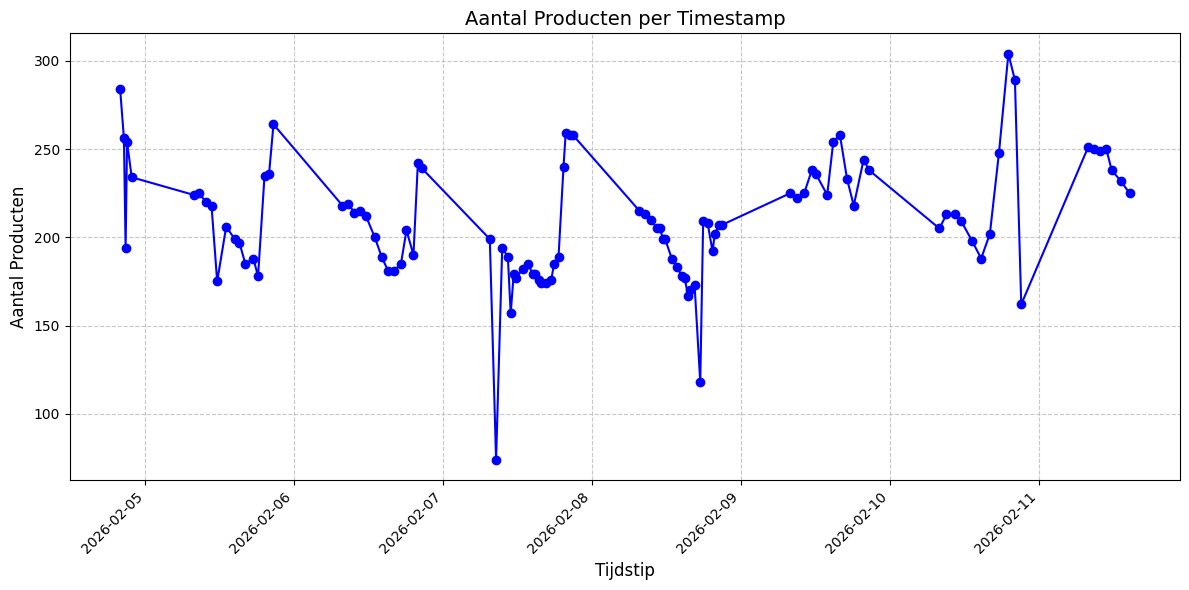

In [14]:
 # 2. Zorg dat de timestamp kolom van het type datetime is
df['fetch_timestamp'] = pd.to_datetime(df['fetch_timestamp'])

# 3. Tel het aantal producten per timestamp
# We groeperen op de 'timestamp' kolom en tellen de rijen (.size())
product_counts = df.groupby('fetch_timestamp').size()

# 4. De plot maken
plt.figure(figsize=(12, 6))
product_counts.plot(kind='line', marker='o', color='b', linestyle='-')

# Opmaak van de grafiek
plt.title('Aantal Producten per Timestamp', fontsize=14)
plt.xlabel('Tijdstip', fontsize=12)
plt.ylabel('Aantal Producten', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()

# Opslaan of tonen
plt.savefig('product_counts_plot.png')
plt.show()

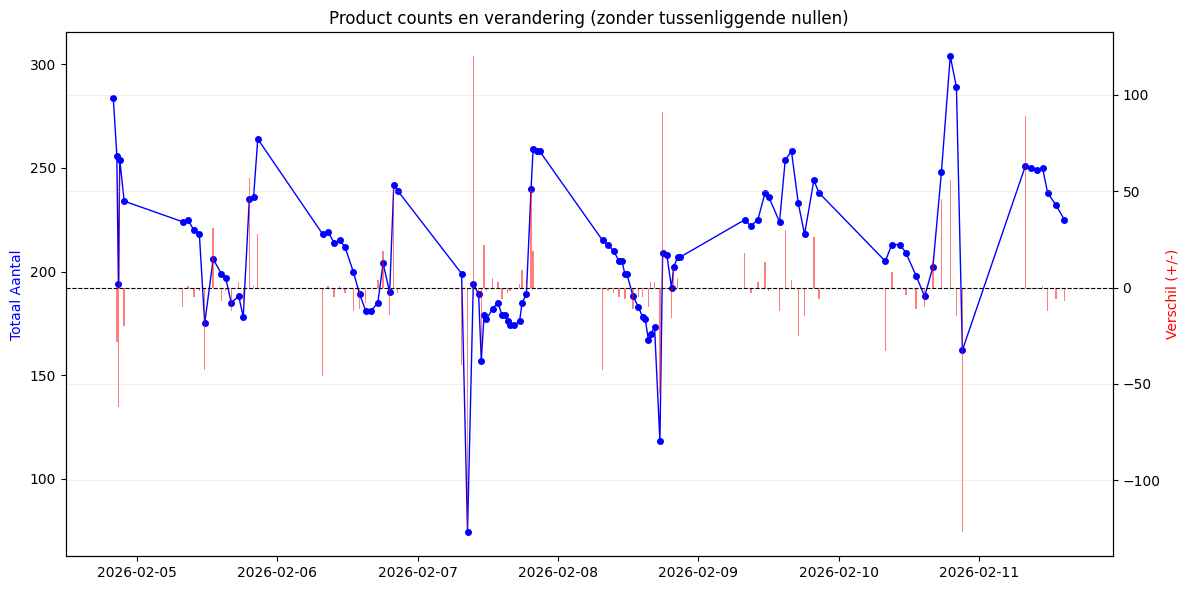

In [22]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Groepeer op de timestamps die je daadwerkelijk HEBT
# We gebruiken .sort_index() om zeker te weten dat de tijdlijn klopt
counts = df.groupby('fetch_timestamp').size().sort_index()

# 2. Bereken de verandering tussen de opeenvolgende meetmomenten
# Dus NIET per minuut, maar van de ene meting naar de volgende
change = counts.diff()

# 3. Plotten
fig, ax1 = plt.subplots(figsize=(12, 6))

# Totaal aantal (Blauwe lijn)
ax1.plot(counts.index, counts, label='Aantal Producten', color='blue', marker='o', markersize=4, linewidth=1)
ax1.set_ylabel('Totaal Aantal', color='blue')

# Verandering (Rode staafjes)
ax2 = ax1.twinx()
ax2.bar(counts.index, change, label='Verandering', color='red', alpha=0.5, width=0.01) # Breedte naar wens aanpassen
ax2.set_ylabel('Verschil (+/-)', color='red')

# Horizontale lijn op 0 voor de duidelijkheid
ax2.axhline(0, color='black', linewidth=0.8, linestyle='--')

plt.title('Product counts en verandering (zonder tussenliggende nullen)')
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

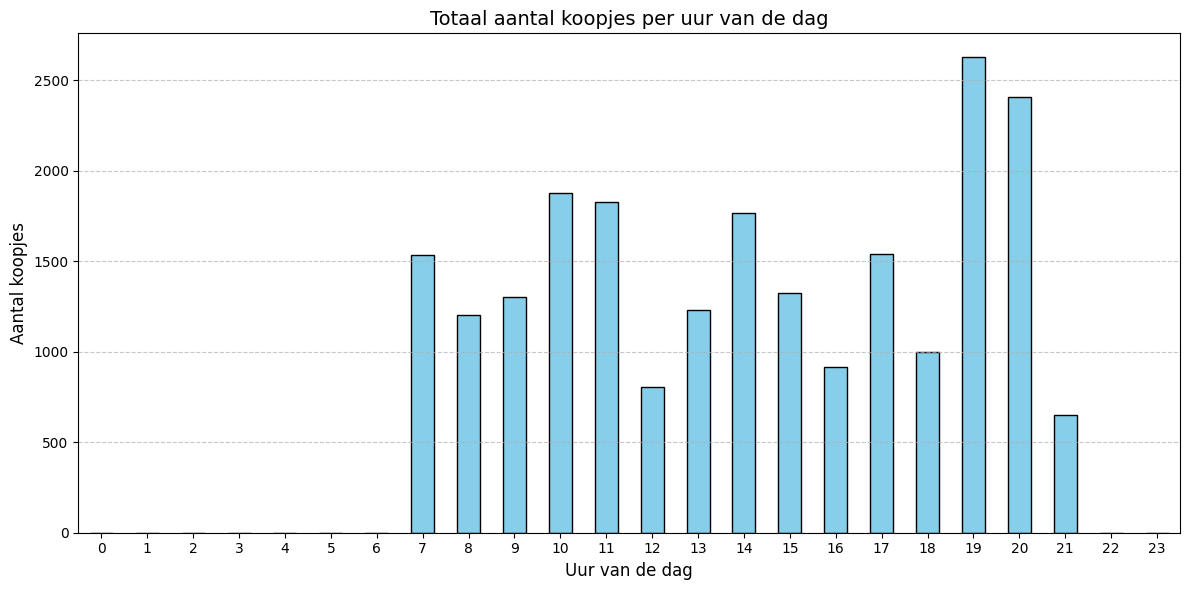

In [23]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Zorg dat de timestamp goed staat
df['fetch_timestamp'] = pd.to_datetime(df['fetch_timestamp'])

# 2. Extraheer het uur (0 t/m 23)
df['hour'] = df['fetch_timestamp'].dt.hour

# 3. Tel het aantal koopjes per uur
hourly_counts = df.groupby('hour').size()

# Zorg dat alle uren (0-23) in de lijst staan, ook als er 0 koopjes waren
hourly_counts = hourly_counts.reindex(range(0, 24), fill_value=0)

# 4. Plotten als staafdiagram
plt.figure(figsize=(12, 6))
hourly_counts.plot(kind='bar', color='skyblue', edgecolor='black')

plt.title('Totaal aantal koopjes per uur van de dag', fontsize=14)
plt.xlabel('Uur van de dag', fontsize=12)
plt.ylabel('Aantal koopjes', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

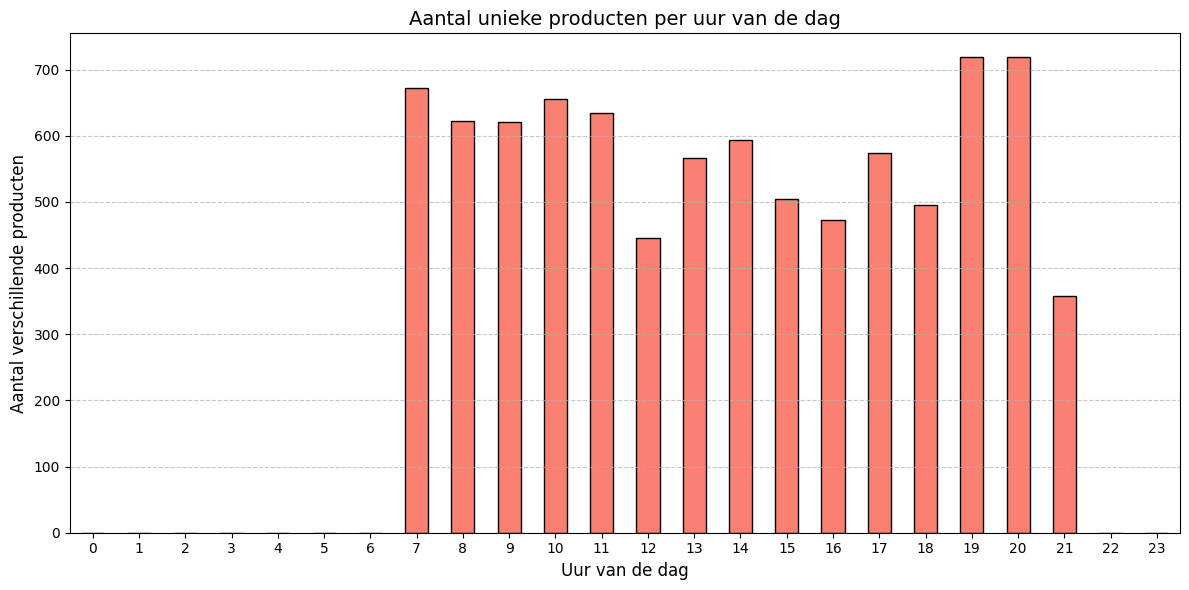

In [33]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Zorg dat de timestamp goed staat
df['fetch_timestamp'] = pd.to_datetime(df['fetch_timestamp'])

# 2. Extraheer het uur (0 t/m 23)
df['hour'] = df['fetch_timestamp'].dt.hour

# 3. Tel het aantal UNIEKE producten per uur
# We gebruiken 'title' (of 'product_id' als je die hebt) om unieke items te tellen
hourly_unique_counts = df.groupby('hour')['title'].nunique()

# Zorg dat alle uren (0-23) in de lijst staan, ook als er 0 unieke koopjes waren
hourly_unique_counts = hourly_unique_counts.reindex(range(0, 24), fill_value=0)

# 4. Plotten als staafdiagram
plt.figure(figsize=(12, 6))
hourly_unique_counts.plot(kind='bar', color='salmon', edgecolor='black') # Kleur aangepast voor onderscheid

plt.title('Aantal unieke producten per uur van de dag', fontsize=14)
plt.xlabel('Uur van de dag', fontsize=12)
plt.ylabel('Aantal verschillende producten', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

C:\Users\20193623\AppData\Local\Temp\ipykernel_37004\1740099455.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[0,0], x='besparing_euro', y='title', data=luxury_catches, palette='viridis')


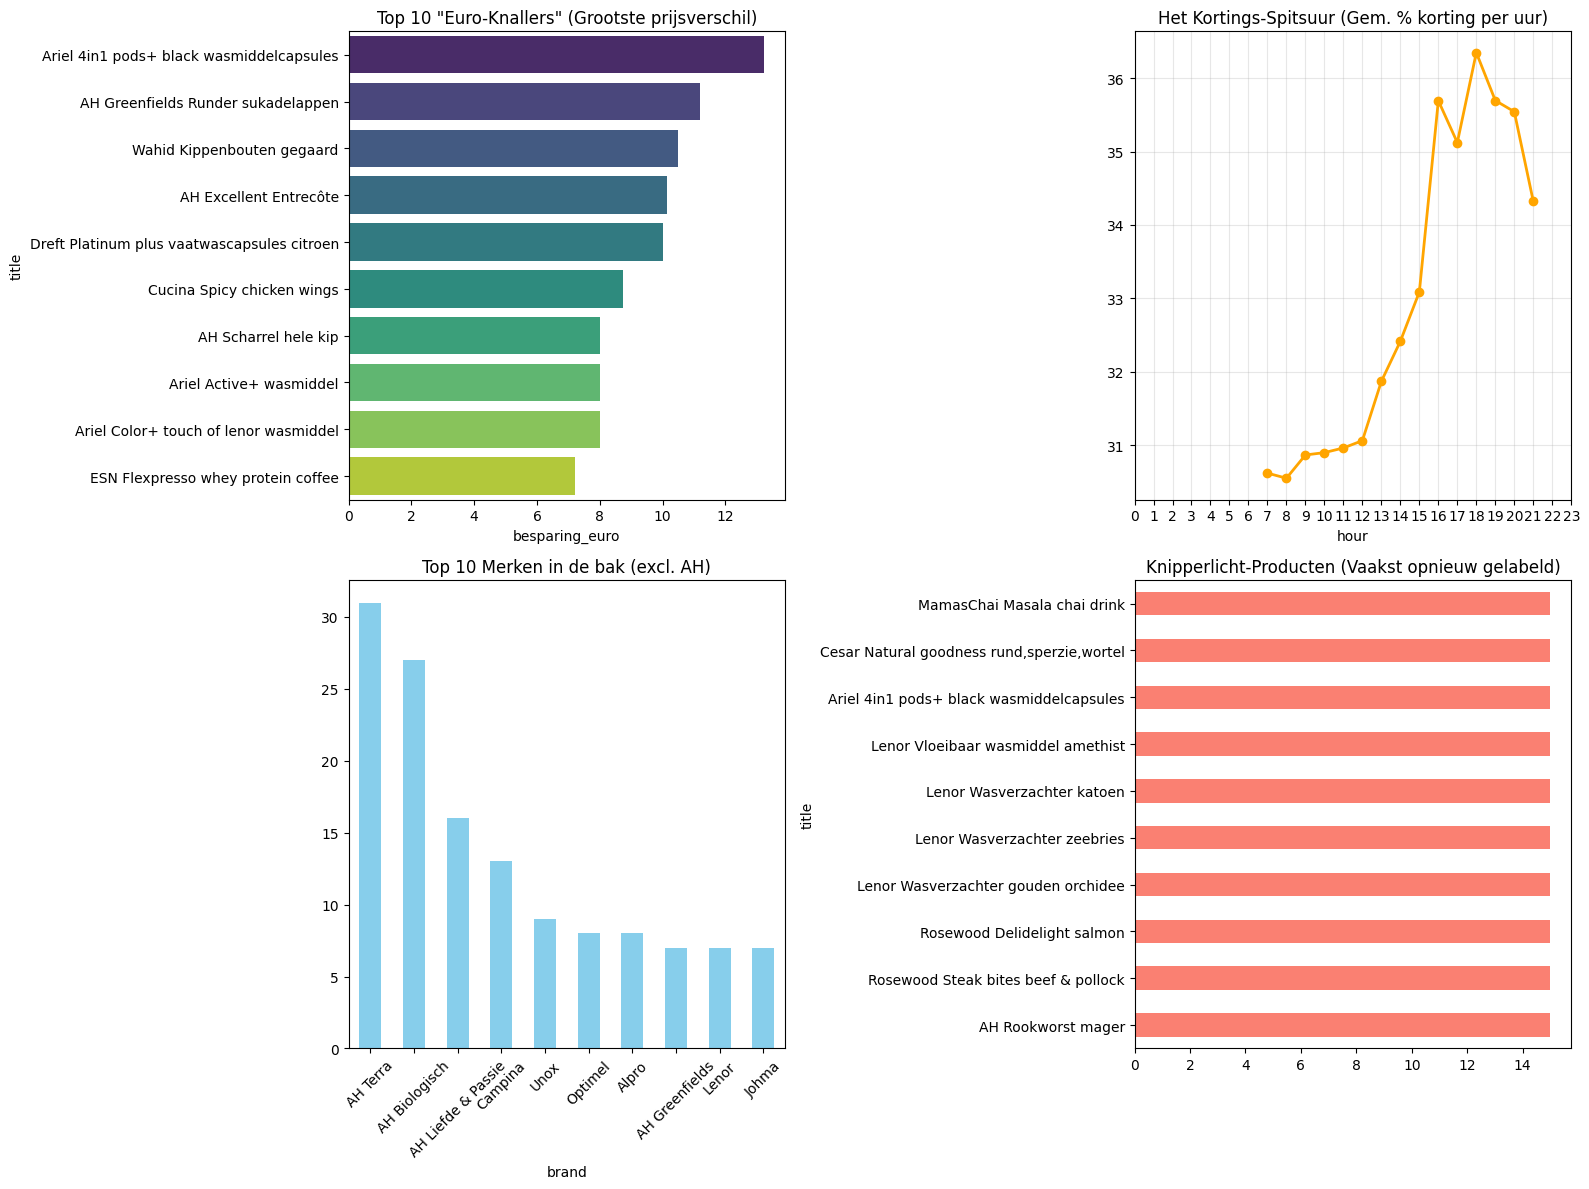

De gemiddelde korting in jouw bakken is: 33.1%
Het duurste product ooit in de bak: Ariel 4in1 pods+ black wasmiddelcapsules (€26.49)


In [38]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Laden en voorbereiden
df = pd.read_csv('laatste_kans_trends.csv')
df['fetch_timestamp'] = pd.to_datetime(df['fetch_timestamp'])
df['hour'] = df['fetch_timestamp'].dt.hour
df['besparing_euro'] = df['priceWas'] - df['priceNow']

# --- INZICHT 1: De Luxury Catch (Grootste besparing in euro's) ---
# We filteren op unieke titels om niet 10x hetzelfde product te zien
luxury_catches = df.sort_values('besparing_euro', ascending=False).drop_duplicates('title').head(10)

# --- INZICHT 2: Het Kortings-Spitsuur ---
# Gemiddeld kortingspercentage per uur van de dag
hourly_deals = df.groupby('hour')['markdownPercentage'].mean()

# --- INZICHT 3: Merken-Dominantie ---
# Welke merken (buiten het huismerk) vullen de bakken?
brand_counts = df[df['brand'] != 'AH'].groupby('brand')['title'].nunique().sort_values(ascending=False).head(10)

# --- INZICHT 4: De 'Knipperlicht' Analyse (Nieuwe instroom) ---
df_sorted = df.sort_values(['title', 'fetch_timestamp'])
df_sorted['gap'] = df_sorted.groupby('title')['fetch_timestamp'].diff()
# Als een product langer dan 1.5 uur weg is geweest, telt het als 'opnieuw toegevoegd'
df_sorted['is_new_entry'] = (df_sorted['gap'] > pd.Timedelta(hours=1.5)) | (df_sorted['gap'].isna())
knipperlichten = df_sorted[df_sorted['is_new_entry']].groupby('title').size().sort_values(ascending=False).head(10)

# --- VISUALISATIE ---
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Euro knallers
sns.barplot(ax=axes[0,0], x='besparing_euro', y='title', data=luxury_catches, palette='viridis')
axes[0,0].set_title('Top 10 "Euro-Knallers" (Grootste prijsverschil)')

# Plot 2: De beste tijd
hourly_deals.plot(ax=axes[0,1], marker='o', color='orange', linewidth=2)
axes[0,1].set_title('Het Kortings-Spitsuur (Gem. % korting per uur)')
axes[0,1].set_xticks(range(0, 24))
axes[0,1].grid(True, alpha=0.3)

# Plot 3: Merken (excl AH)
brand_counts.plot(ax=axes[1,0], kind='bar', color='skyblue')
axes[1,0].set_title('Top 10 Merken in de bak (excl. AH)')
axes[1,0].tick_params(axis='x', rotation=45)

# Plot 4: Knipperlichten
knipperlichten.plot(ax=axes[1,1], kind='barh', color='salmon')
axes[1,1].set_title('Knipperlicht-Producten (Vaakst opnieuw gelabeld)')

plt.tight_layout()
plt.show()

# Print de leukste feitjes
print(f"De gemiddelde korting in jouw bakken is: {df['markdownPercentage'].mean():.1f}%")
print(f"Het duurste product ooit in de bak: {df.loc[df['priceWas'].idxmax(), 'title']} (€{df['priceWas'].max()})")